# Fitting mock data end-to-end

This tutorial runs the full SuperMAGE inference recipe on a mock ALMA-like
dataset:

1. **simulate** noisy visibilities from a known galaxy;
2. **global search** — Sobol scouts pruned by a cheap χ² pass, each survivor
   polished with Levenberg–Marquardt (`sobol_ga_swarm_no_nan`);
3. **Laplace approximation** — the Gauss–Newton Hessian at the best fit
   gives an excellent posterior covariance estimate;
4. **MCMC** — gradient-based MALA, preconditioned with that covariance.

Everything below runs in a few minutes on a single consumer GPU. A real
analysis is the same code with more channels, more pixels, more free
parameters and longer chains — or a nested sampler plugged into the same
forward model (see the end of the notebook).

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from supermage.simulators.intensity_models import ExponentialDisk2D
from supermage.simulators.velocity_models import SersicMGE
from supermage.simulators.analytic_cube import AnalyticInverse
from supermage.simulators.visibility_cube import VisibilityCubePadded
from supermage.solvers.optimizers import lm_direct
from supermage.solvers.swarm_optimization import sobol_ga_swarm_no_nan
from supermage.solvers.MCMC import mala, log_prior_tophat_vmappable
from supermage.utils.likelihood import gaussian_loglike

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float32
torch.manual_seed(0)

## 1. The mock observation

Same setup as the [visibilities tutorial](04_visibilities.ipynb): a Sérsic
galaxy with a $10^{8.5}\,M_\odot$ black hole, observed through an annular
uv mask.

In [2]:
line_hz = 230.538e9
c_kms = 299792.458
n_chan = 30
df = line_hz * (700.0 / c_kms) / (n_chan - 1)
freqs = line_hz + (np.arange(n_chan) - (n_chan - 1) / 2) * df

pixscale, n_pix_img, n_pix_uv = 0.1, 71, 101

intensity_model = ExponentialDisk2D()
velocity_model = SersicMGE(N_MGE_components=20, distance_Mpc=16.5, soft=1.0,
                           device=device, dtype=dtype)
cube_sim = AnalyticInverse(intensity_model, velocity_model, freqs,
                           pixel_scale_arcsec=pixscale, N_pix_x=n_pix_img,
                           K_vel=8, oversamp_xy=4, oversamp_v=4,
                           device=device, dtype=dtype, line=line_hz)

u = np.fft.fftshift(np.fft.fftfreq(n_pix_uv))
uu, vv = np.meshgrid(u, u)
mask2d = (np.hypot(uu, vv) > 0.03) & (np.hypot(uu, vv) < 0.42)
mask = np.repeat(mask2d[None], n_chan, axis=0)

vis_sim = VisibilityCubePadded(cube_sim, mask, freqs, npix=n_pix_uv,
                               pixelscale=pixscale, dish_diameter=12.0,
                               line=line_hz)

truth = {
    "scale": 400.0, "qintr": 0.6, "m_bh": 8.5, "n": 4.0, "r_e": 25.0,
    "intensity_r_e": 2.8, "inclination": np.deg2rad(60.0),
    "sky_rot": np.deg2rad(30.0), "line_broadening": 10.0,
    "velocity_shift": 0.0, "x0": 0.0, "y0": 0.0, "distance_pc": 16.5e6,
    "flux": 50.0,
}

## 2. Choose the free parameters

To keep the tutorial fast we fit **four** parameters — gas scale length,
black-hole mass, inclination and total flux — and freeze the rest at the
truth with `Param.to_static()`. (A publication fit frees everything; the
code is identical, just slower.)

In [3]:
free = ["scale", "m_bh", "inclination", "flux"]
for p in list(vis_sim.dynamic_params):
    if p.name not in free:
        val = truth[p.name]
        val = [val] if (p.shape is not None and p.shape == (1,)) else val
        p.to_static(torch.tensor(val, device=device, dtype=dtype))

print("free parameters:", [p.name for p in vis_sim.dynamic_params])
theta_true = torch.tensor([truth[p.name] for p in vis_sim.dynamic_params],
                          device=device, dtype=dtype)

free parameters: ['scale', 'm_bh', 'inclination', 'flux']


## 3. Simulate the data

The forward function flattens the complex visibilities into a real vector
`[Re..., Im...]` — the layout every solver below consumes. We add
homoscedastic Gaussian noise per uv cell.

In [4]:
def fwd(theta):
    out = vis_sim.forward(theta)
    return torch.cat([out.real.flatten(), out.imag.flatten()])

sigma_noise = 0.002    # Jy per uv cell (per Re/Im component)
y_clean = fwd(theta_true)
Y = y_clean + sigma_noise * torch.randn_like(y_clean)

C = torch.full_like(Y, sigma_noise**2)       # per-datum variance
sqrt_Cinv = torch.full_like(Y, 1.0 / sigma_noise)
n_chi = Y.numel()
print(f"data vector: {n_chi:,} numbers "
      f"(2 x {n_chan} channels x {int(mask2d.sum()):,} uv cells incl. masked zeros)")
print(f"peak |V| / noise = {float(y_clean.abs().max()) / sigma_noise:.0f}")

data vector: 612,060 numbers (2 x 30 channels x 5,608 uv cells incl. masked zeros)
peak |V| / noise = 42


## 4. Global search: Sobol scouts + LM refinement

χ² surfaces of kinematic fits are multi-modal, so never trust a single
local optimization from a guess. `sobol_ga_swarm_no_nan` draws
low-discrepancy scouts across the prior box, evaluates χ² for each (no
gradients — cheap), keeps the best fraction and polishes each survivor
with Levenberg–Marquardt:

In [5]:
bounds = [
    (200.0, 800.0),                        # scale [pc]
    (7.5, 9.5),                            # log10 M_BH
    (np.deg2rad(40.0), np.deg2rad(80.0)),  # inclination [rad]
    (20.0, 100.0),                         # flux [Jy km/s]
]

best_X, best_chi2, best_L, history = sobol_ga_swarm_no_nan(
    lm_direct, bounds,
    n_particles=4, n_chi=n_chi,
    oversample=8,          # 32 scouts
    keep_frac=0.125,       # -> 4 LM runs
    device=device, dtype=dtype,
    lm_kwargs=dict(Y=Y, f=fwd, n_chi=n_chi, C=C, max_iter=12, verbose=False),
    seed=7,
)
best_X = best_X.to(dtype)
print("\nbest swarm result:", best_X.tolist())

Pruning Sobol' swarm:   0%|          | 0/32 [00:00<?, ?it/s]

Pruning Sobol' swarm:  59%|█████▉    | 19/32 [00:00<00:00, 180.43it/s]

Pruning Sobol' swarm: 100%|██████████| 32/32 [00:00<00:00, 190.88it/s]

Scouted 32 points, found 32 valid, best raw χ² = 1.134
Keeping 4 best points for LM refinement …
[1.13437306 1.40592436 1.42237056 1.50957198]


[  1/4] χ²=6.114e+05   best=6.114e+05


[  2/4] χ²=6.114e+05   best=6.114e+05


[  3/4] χ²=6.114e+05   best=6.114e+05


[  4/4] χ²=6.114e+05   best=6.114e+05

best swarm result: [400.93243408203125, 8.499192237854004, 1.0472426414489746, 50.062232971191406]


In [6]:
# Final polish from the swarm's best point
X_fit, L_fit, chi2_fit = lm_direct(best_X.clone(), Y, fwd, n_chi, C=C,
                                   max_iter=30, verbose=False)
print(f"chi^2/n = {float(chi2_fit)/n_chi:.5f}  (1.0 = noise level)")
for p, t, f in zip(vis_sim.dynamic_params, theta_true, X_fit):
    print(f"{p.name:12s} truth {float(t):10.4f}   fit {float(f):10.4f}")

chi^2/n = 0.99896  (1.0 = noise level)
scale        truth   400.0000   fit   400.9324
m_bh         truth     8.5000   fit     8.4992
inclination  truth     1.0472   fit     1.0472
flux         truth    50.0000   fit    50.0622


## 5. Laplace approximation

At the optimum, the Gauss–Newton Hessian `H = Jᵀ C⁻¹ J` is the inverse
posterior covariance under the Gaussian (Laplace) approximation. With
forward-mode autodiff the exact Jacobian of the *whole pipeline* is four
forward passes:

In [7]:
from torch.func import jacfwd

J = jacfwd(fwd)(X_fit)                          # (n_data, 4)
H = J.T @ (J / C[:, None])
Sigma = torch.linalg.inv(H.double()).to(dtype)  # posterior covariance estimate
sig_laplace = torch.sqrt(torch.diag(Sigma))
for p, s in zip(vis_sim.dynamic_params, sig_laplace):
    print(f"sigma({p.name:12s}) = {float(s):.3e}")

sigma(scale       ) = 1.417e+00
sigma(m_bh        ) = 5.557e-04
sigma(inclination ) = 2.643e-04
sigma(flux        ) = 6.039e-02


## 6. MALA: gradient-based posterior sampling

The Metropolis-adjusted Langevin algorithm drifts each proposal along the
log-posterior gradient. Preconditioned with the Laplace covariance as its
mass matrix, it mixes essentially immediately. `gaussian_loglike` performs
the χ² reduction in float64 — with ~600k data points a float32 sum
quantizes the log-likelihood badly enough to stall samplers.

In [8]:
low  = torch.tensor([b[0] for b in bounds], device=device, dtype=dtype)
high = torch.tensor([b[1] for b in bounds], device=device, dtype=dtype)

def log_prob(theta):
    return (gaussian_loglike(fwd(theta), Y, sqrt_Cinv)
            + log_prior_tophat_vmappable(theta, low, high))

n_chains = 4
L_chol = torch.linalg.cholesky(Sigma.double()).to(dtype)
init = X_fit.unsqueeze(0) + torch.randn(n_chains, 4, device=device) @ L_chol.T

samples, acc, chi2_trace = mala(
    log_prob, init, n_steps=400, step_size=0.8,
    mass_matrix=Sigma, progress=False,
)
print(f"acceptance rate: {acc.mean():.2f}")

acceptance rate: 0.91


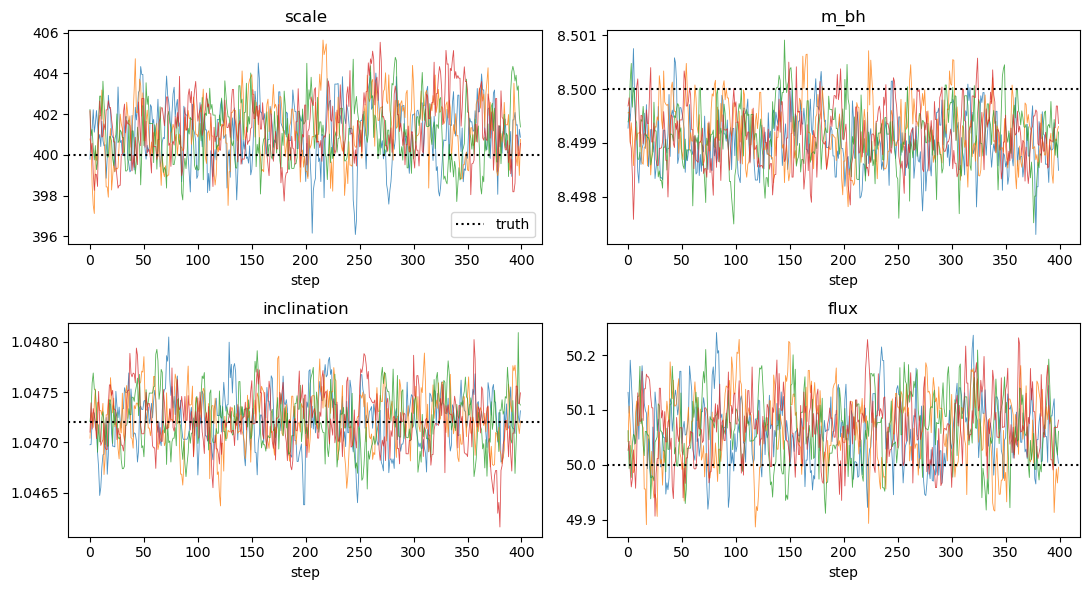

In [9]:
names = [p.name for p in vis_sim.dynamic_params]
burn = 100
chain = samples[burn:].reshape(-1, 4)

fig, axes = plt.subplots(2, 2, figsize=(11, 6))
for k, (ax, name) in enumerate(zip(axes.ravel(), names)):
    for c in range(n_chains):
        ax.plot(samples[:, c, k], lw=0.6, alpha=0.8)
    ax.axhline(float(theta_true[k]), color="k", ls=":", lw=1.5, label="truth")
    ax.set_title(name); ax.set_xlabel("step")
axes[0, 0].legend()
plt.tight_layout(); plt.show()

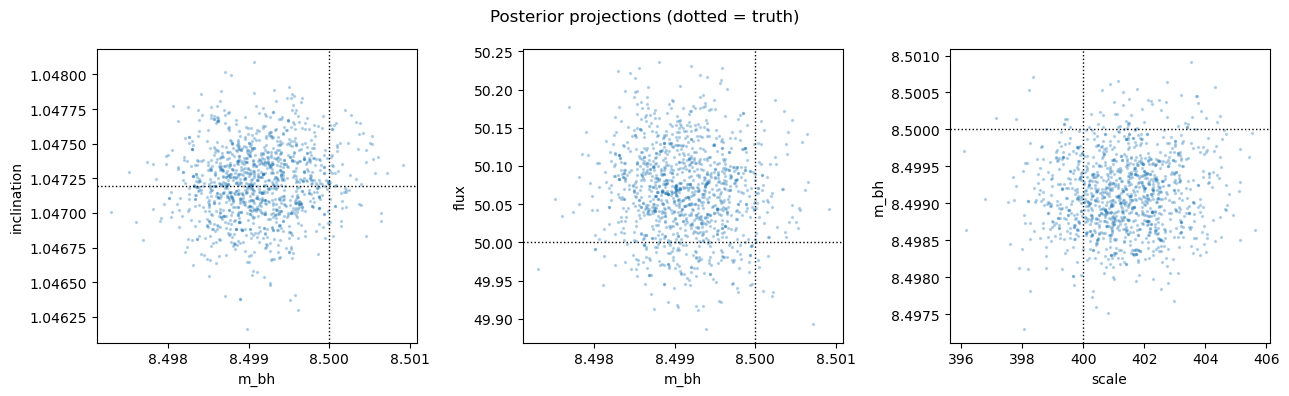

param             truth  posterior mean   MCMC sigma  Laplace sigma
scale          400.0000        401.2972     1.46e+00       1.42e+00
m_bh             8.5000          8.4991     5.25e-04       5.56e-04
inclination      1.0472          1.0472     2.65e-04       2.64e-04
flux            50.0000         50.0671     5.79e-02       6.04e-02


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
pairs = [(1, 2), (1, 3), (0, 1)]
for ax, (i, j) in zip(axes, pairs):
    ax.scatter(chain[:, i], chain[:, j], s=2, alpha=0.25)
    ax.axvline(float(theta_true[i]), color="k", ls=":", lw=1)
    ax.axhline(float(theta_true[j]), color="k", ls=":", lw=1)
    ax.set_xlabel(names[i]); ax.set_ylabel(names[j])
fig.suptitle("Posterior projections (dotted = truth)")
plt.tight_layout(); plt.show()

print(f"{'param':12s} {'truth':>10s} {'posterior mean':>15s} {'MCMC sigma':>12s} {'Laplace sigma':>14s}")
for k, name in enumerate(names):
    print(f"{name:12s} {float(theta_true[k]):10.4f} {chain[:, k].mean():15.4f} "
          f"{chain[:, k].std():12.2e} {float(sig_laplace[k]):14.2e}")

The MCMC widths agree with the Laplace estimate — as they should for a
near-Gaussian, high-SNR posterior. On real data with strong degeneracies
(inclination–mass, M/L–mass) the MCMC and the Laplace approximation part
ways, and that difference is exactly why you run the sampler.

## 7. Scaling up to real analyses

- **Long runs on clusters** — `checkpointed_mala` is the same sampler with
  periodic `.npz` checkpoints and transparent resume after wall-clock
  kills.
- **Nested sampling** — the same `fwd` slots into UltraNest/Nautilus-style
  vectorised likelihoods;
  `supermage.utils.likelihood.build_multi_gpu_log_likelihood` fans a
  `(N, D)` batch of parameter vectors out over multiple GPUs, with
  `torch.func.vmap` batching within each GPU and automatic OOM fallback.
- **Real gridded data** — `supermage.utils.likelihood.load_raw_data` loads
  a `viscube` `.npz` (validating the half-plane/taper conventions of the
  [visibilities tutorial](04_visibilities.ipynb)), and
  `build_data_tensors` produces the `(vis_flat, sqrt_Cinv)` pair used
  above from the gridder's per-cell noise estimates.
- **More free parameters** — simply skip the `to_static` calls; nothing
  else changes. Costs grow with the Jacobian width in LM (one
  forward-mode pass per parameter) but not in MALA (one backward pass
  gives all gradients).